# SGP4 Cross-Validation — RK4+J2 Propagator vs. SGP4

This notebook checks this project's numerical propagator (RK4 with Gravity + J2)
against the project's own from-scratch SGP4 implementation ([src/orbit/SGP4.h](../src/orbit/SGP4.h)),
both seeded from the same real-world TLE (ISS, catalog #25544).

This is a **cross-validation between two propagators built for different purposes**:

- **RK4**: a configurable-fidelity numerical integrator meant for trade studies — you can
  toggle J2/J3/J4, drag, SRP, third-body gravity independently.
- **SGP4**: the NORAD analytic standard used to propagate published TLEs, with its own
  internal (WGS72) gravity model and a built-in drag term (BSTAR).

Agreement here shows the two propagators describe *the same orbit*, which is a useful
sanity check on both implementations. It is **not** a substitute for validating SGP4 against
an external reference implementation — that check lives in
[`tests/test_sgp4.cpp`](../tests/test_sgp4.cpp), which compares this SGP4 implementation
against the published Spacetrack Report #3 / Vallado (AIAA 2006-6753) verification vector.

**To regenerate the data this notebook reads:**
```bash
cmake -B build && cmake --build build -j
./build/sgp4_validation
```
This writes `output/sgp4_validation/comparison.csv` (run from the repo root, matching the
convention used by `ConstellationSim` itself).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib

df = pd.read_csv(pathlib.Path('../build/output/sgp4_validation/comparison.csv'))
df.head()

,time_hours,rk4_x_km,rk4_y_km,rk4_z_km,sgp4_x_km,sgp4_y_km,sgp4_z_km,separation_km,rk4_alt_km,sgp4_alt_km
0,0.000000,6391.421148,-2327.607390,8.326904,6391.421148,-2327.607390,8.326904,0.000000,423.928112,423.928112
1,0.166667,5882.983273,664.320380,3340.558558,5882.979654,664.316607,3340.554285,0.006752,419.667442,419.661842
2,0.333333,2788.682634,3364.324512,5200.501272,2788.675836,3364.319707,5200.488916,0.014899,414.553464,414.538833
3,0.500000,-1531.162429,4585.465466,4768.261958,-1531.172507,4585.451186,4768.243448,0.025458,412.096724,412.076355
4,0.666667,-5176.191491,3787.897831,2231.366311,-5176.199347,3787.862269,2231.344591,0.042405,413.042864,413.021880


## 1 · Position separation over time

Both propagators start from an identical state (SGP4's osculating state at the TLE epoch).
The RK4 propagator here only models Gravity + J2 — it has no drag term, while SGP4's BSTAR
does model drag internally, and the two J2 formulations differ in higher-order detail. The
separation should grow slowly and smoothly, not blow up or oscillate erratically (which
would indicate a bug in one of the propagators, not just a modeling-fidelity difference).

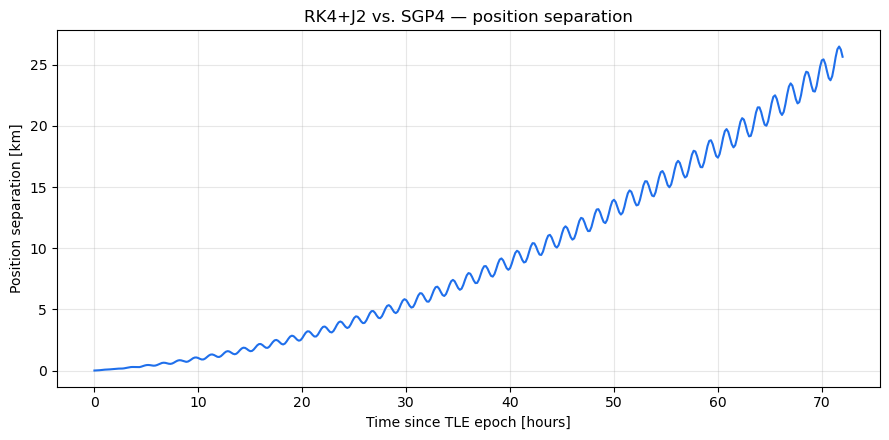

Separation at t=0:      0.0000 km
Separation at t=1 hour: 0.0711 km
Separation at t=24h:    3.756 km
Separation at t=72h:    25.655 km


In [2]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df['time_hours'], df['separation_km'], lw=1.5, color='#1f6feb')
ax.set_xlabel('Time since TLE epoch [hours]')
ax.set_ylabel('Position separation [km]')
ax.set_title('RK4+J2 vs. SGP4 — position separation')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Separation at t=0:      {df['separation_km'].iloc[0]:.4f} km")
print(f"Separation at t=1 hour: {df[df['time_hours'] >= 1.0]['separation_km'].iloc[0]:.4f} km")
print(f"Separation at t=24h:    {df[df['time_hours'] >= 24.0]['separation_km'].iloc[0]:.3f} km")
print(f"Separation at t=72h:    {df['separation_km'].iloc[-1]:.3f} km")

## 2 · Altitude comparison

A second, independent view of the same agreement: both propagators' altitude time
histories should track closely, with the RK4 trace staying essentially flat relative to
SGP4's (since neither models drag the same way, but J2's altitude effect is negligible —
J2 perturbs the orbit plane and argument of perigee, not the semi-major axis, to first
order).

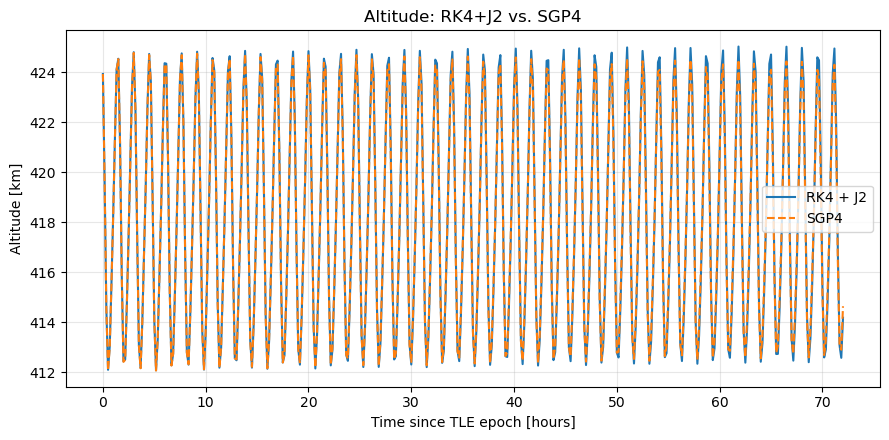

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df['time_hours'], df['rk4_alt_km'], label='RK4 + J2', lw=1.5)
ax.plot(df['time_hours'], df['sgp4_alt_km'], label='SGP4', lw=1.5, linestyle='--')
ax.set_xlabel('Time since TLE epoch [hours]')
ax.set_ylabel('Altitude [km]')
ax.set_title('Altitude: RK4+J2 vs. SGP4')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3 · Takeaway

Sub-kilometer agreement over the first several hours, growing to tens of kilometers by
72 hours, is the expected signature of two orbit propagators built on shared two-body +
J2 physics but differing in force-model completeness (SGP4's BSTAR drag vs. RK4's pure
gravity+J2 here) and formulation details — not a red flag. If this separation instead grew
without bound in the first few steps, or the altitude traces diverged immediately, that
would indicate a units or sign-convention bug in one of the propagators.